# Bank Marketing Campaign Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load & Inspect the Data

In [2]:
df = pd.read_csv('/content/banking_data.csv')
df.head()

,age,job,marital,marital_status,education,default,balance,housing,loan,contact,day,month,day_month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,married,tertiary,no,2143,yes,no,unknown,5,may,5-May,261,1,-1,0,unknown,no
1,44,technician,single,single,secondary,no,29,yes,no,unknown,5,may,5-May,151,1,-1,0,unknown,no
2,33,entrepreneur,married,married,secondary,no,2,yes,yes,unknown,5,may,5-May,76,1,-1,0,unknown,no
3,47,blue-collar,married,married,unknown,no,1506,yes,no,unknown,5,may,5-May,92,1,-1,0,unknown,no
4,33,unknown,single,single,unknown,no,1,no,no,unknown,5,may,5-May,198,1,-1,0,unknown,no


In [3]:
df.shape

(45216, 19)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45216 entries, 0 to 45215
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45216 non-null  int64 
 1   job             45216 non-null  object
 2   marital         45213 non-null  object
 3   marital_status  45213 non-null  object
 4   education       45213 non-null  object
 5   default         45216 non-null  object
 6   balance         45216 non-null  int64 
 7   housing         45216 non-null  object
 8   loan            45216 non-null  object
 9   contact         45216 non-null  object
 10  day             45216 non-null  int64 
 11  month           45216 non-null  object
 12  day_month       45216 non-null  object
 13  duration        45216 non-null  int64 
 14  campaign        45216 non-null  int64 
 15  pdays           45216 non-null  int64 
 16  previous        45216 non-null  int64 
 17  poutcome        45216 non-null  object
 18  y     

### 2. Data Cleaning
Checking for duplicate rows and redundant/derived columns before doing any analysis.

In [5]:
df.duplicated().sum()

np.int64(5)

In [6]:
df.drop_duplicates(inplace = True)

In [7]:
df.columns

Index(['age', 'job', 'marital', 'marital_status', 'education', 'default',
       'balance', 'housing', 'loan', 'contact', 'day', 'month', 'day_month',
       'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [8]:
is_identical = df['marital'].equals(df['marital_status'])
print(f'Marital and Marital_status are identical: {is_identical}')

Marital and Marital_status are identical: True


In [11]:
df['pdays'].value_counts().sort_index()

,count
pdays,
-1,36954
1,15
2,37
3,1
4,2
...,...
838,1
842,1
850,1


In [10]:
def was_previously_contacted(x):
  if x == -1:
    return 'no'
  else:
    return 'yes'

df['was_previously_contacted'] = df['pdays'].apply(was_previously_contacted)
df.head()

,age,job,marital,marital_status,education,default,balance,housing,loan,contact,day,month,day_month,duration,campaign,pdays,previous,poutcome,y,was_previously_contacted
0,58,management,married,married,tertiary,no,2143,yes,no,unknown,5,may,5-May,261,1,-1,0,unknown,no,no
1,44,technician,single,single,secondary,no,29,yes,no,unknown,5,may,5-May,151,1,-1,0,unknown,no,no
2,33,entrepreneur,married,married,secondary,no,2,yes,yes,unknown,5,may,5-May,76,1,-1,0,unknown,no,no
3,47,blue-collar,married,married,unknown,no,1506,yes,no,unknown,5,may,5-May,92,1,-1,0,unknown,no,no
4,33,unknown,single,single,unknown,no,1,no,no,unknown,5,may,5-May,198,1,-1,0,unknown,no,no


In [12]:
df['duration'].describe()

,duration
count,45211.000000
mean,258.163080
std,257.527812
min,0.000000
25%,103.000000
50%,180.000000
75%,319.000000
max,4918.000000


### 3. Exploratory Data Analysis
Looking at how housing loans, personal loans, education, and job relate to subscription rate.

In [13]:
df['housing'].value_counts()

,count
housing,
yes,25130
no,20081


In [14]:
df.groupby('housing')['y'].value_counts()

housing  y  
no       no     16727
         yes     3354
yes      no     23195
         yes     1935
Name: count, dtype: int64

In [15]:
df['loan'].value_counts()

,count
loan,
no,37967
yes,7244


In [16]:
df.groupby('loan')['y'].value_counts()

loan  y  
no    no     33162
      yes     4805
yes   no      6760
      yes      484
Name: count, dtype: int64

In [17]:
df.groupby(['housing', 'loan'])['y'].value_counts()

housing  loan  y  
no       no    no     14069
               yes     3135
         yes   no      2658
               yes      219
yes      no    no     19093
               yes     1670
         yes   no      4102
               yes      265
Name: count, dtype: int64

In [18]:
df['education'].value_counts()

,count
education,
secondary,23202
tertiary,13299
primary,6850
unknown,1857


In [20]:
df.groupby('education')['y'].value_counts()

education  y  
primary    no      6259
           yes      591
secondary  no     20752
           yes     2450
tertiary   no     11304
           yes     1995
unknown    no      1605
           yes      252
Name: count, dtype: int64

In [21]:
pd.crosstab(df['job'], df['education'],normalize='index')*100

education,primary,secondary,tertiary,unknown
job,,,,
admin.,4.041771,81.589635,11.061690,3.306904
blue-collar,38.614879,55.189067,1.531032,4.665023
entrepreneur,12.306658,36.449227,46.133154,5.110962
housemaid,50.564516,31.854839,13.951613,3.629032
management,3.109137,11.854907,82.476734,2.559222
retired,35.114841,43.462898,16.166078,5.256184
self-employed,8.233059,36.542115,52.754908,2.469918
services,8.305248,83.220992,4.862783,3.610977
student,4.589114,54.215582,23.799360,17.395945


In [22]:
df.groupby(['job', 'education'])['y'].value_counts(normalize=True)*100

job      education  y  
admin.   primary    no     94.258373
                    yes     5.741627
         secondary  no     88.101446
                    yes    11.898554
         tertiary   no     82.692308
                             ...    
unknown  secondary  yes    12.676056
         tertiary   no     89.743590
                    yes    10.256410
         unknown    no     85.826772
                    yes    14.173228
Name: proportion, Length: 96, dtype: float64

Tertiary-educated customers show a higher subscription rate than primary/secondary. However, job type is strongly correlated with education level (e.g. management is heavily tertiary-educated, blue-collar is not), so this relationship may be at least partly explained by job rather than education itself. I did not explore further here.

### 4. Campaign Contact Frequency
Grouping the number of contact attempts into buckets to see if calling someone repeatedly actually helps.

In [23]:
df['campaign'].value_counts().sort_index()

,count
campaign,
1,17544
2,12505
3,5521
4,3522
5,1764
6,1291
7,735
8,540
9,327


In [24]:
def bucket_campaign(x):
  if x == 1:
    return '1'
  elif x <= 3:
    return '2-3'
  elif x <= 6:
    return '4-6'
  else: return '7+'

df['campaign_bucket'] = df['campaign'].apply(bucket_campaign)
df.head()

,age,job,marital,marital_status,education,default,balance,housing,loan,contact,...,month,day_month,duration,campaign,pdays,previous,poutcome,y,was_previously_contacted,campaign_bucket
0,58,management,married,married,tertiary,no,2143,yes,no,unknown,...,may,5-May,261,1,-1,0,unknown,no,no,1
1,44,technician,single,single,secondary,no,29,yes,no,unknown,...,may,5-May,151,1,-1,0,unknown,no,no,1
2,33,entrepreneur,married,married,secondary,no,2,yes,yes,unknown,...,may,5-May,76,1,-1,0,unknown,no,no,1
3,47,blue-collar,married,married,unknown,no,1506,yes,no,unknown,...,may,5-May,92,1,-1,0,unknown,no,no,1
4,33,unknown,single,single,unknown,no,1,no,no,unknown,...,may,5-May,198,1,-1,0,unknown,no,no,1


In [25]:
df['campaign_bucket'].value_counts().sort_index()

,count
campaign_bucket,
1,17544
2-3,18026
4-6,6577
7+,3064


In [26]:
df.groupby('campaign_bucket')['y'].value_counts(normalize=True)*100

campaign_bucket  y  
1                no     85.402417
                 yes    14.597583
2-3              no     88.799512
                 yes    11.200488
4-6              no     91.667934
                 yes     8.332066
7+               no     94.745431
                 yes     5.254569
Name: proportion, dtype: float64

#**Visualizations**

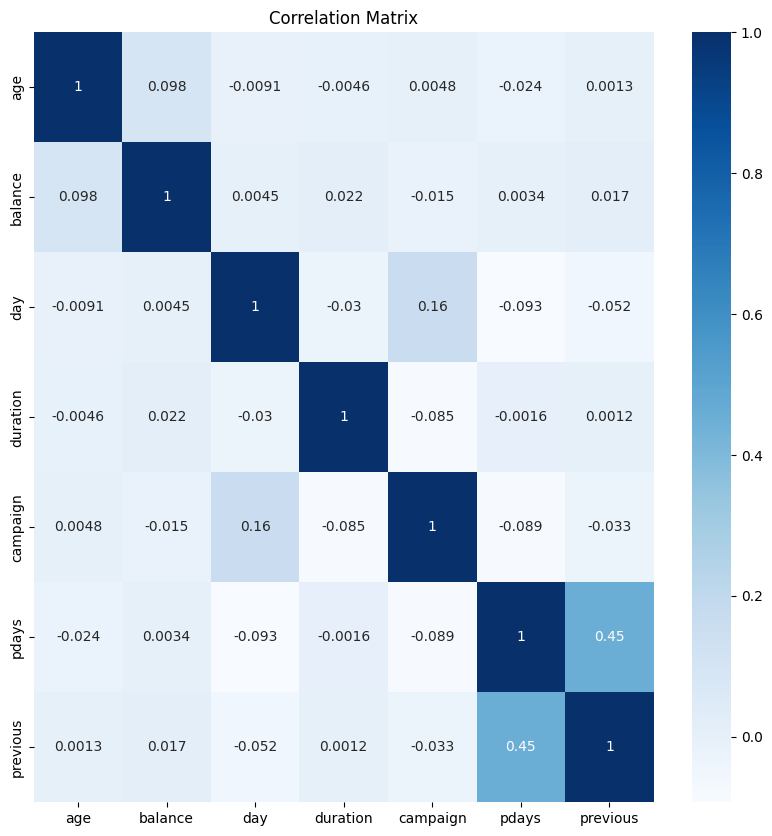

In [27]:
#correlation matrix

df_corr = df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(10,10))
sns.heatmap(df_corr.corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

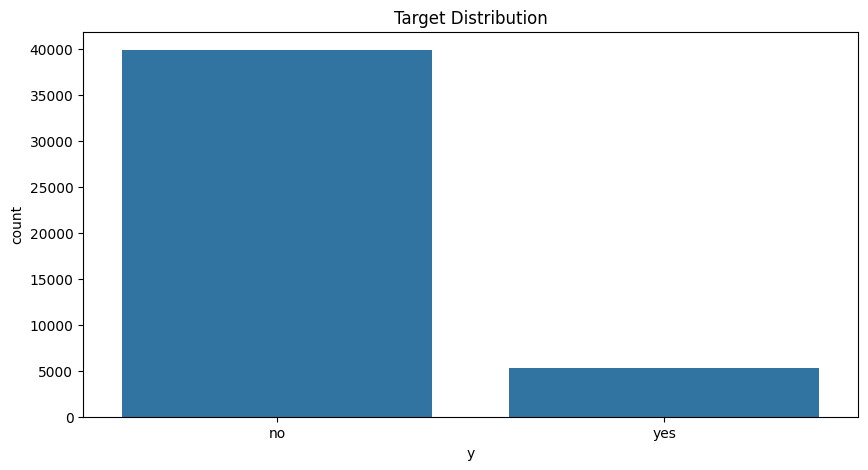

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(x='y', data=df)
plt.title('Target Distribution')
plt.show()

Interpretation - 88/12 imbalance

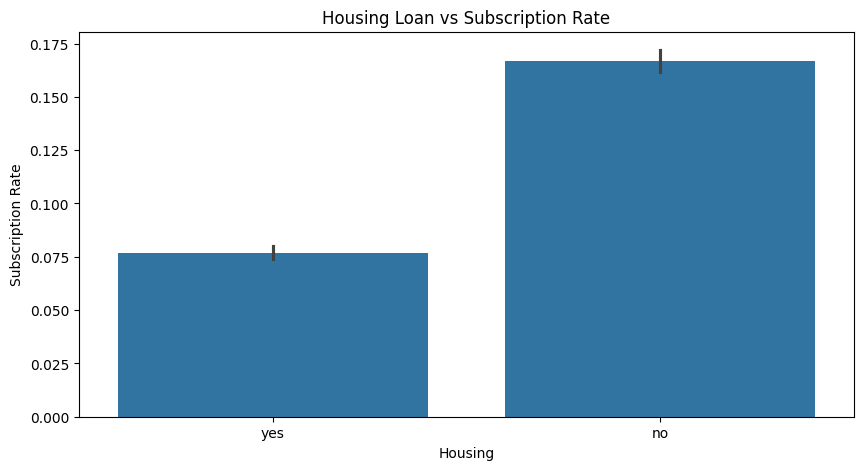

In [32]:
plt.figure(figsize=(10,5))
sns.barplot(x='housing', y=df['y'].map({'yes': 1, 'no': 0}), data=df)
plt.title('Housing Loan vs Subscription Rate')
plt.xlabel('Housing')
plt.ylabel('Subscription Rate')
plt.show()

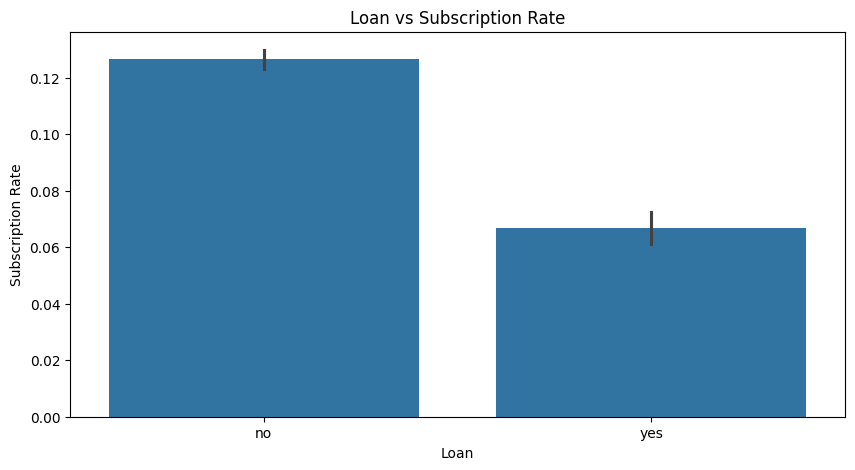

In [30]:
plt.figure(figsize=(10,5))
sns.barplot(data = df, x='loan', y=df['y'].map({'yes':1, 'no':0}))
plt.title('Loan vs Subscription Rate')
plt.xlabel('Loan')
plt.ylabel('Subscription Rate')
plt.show()

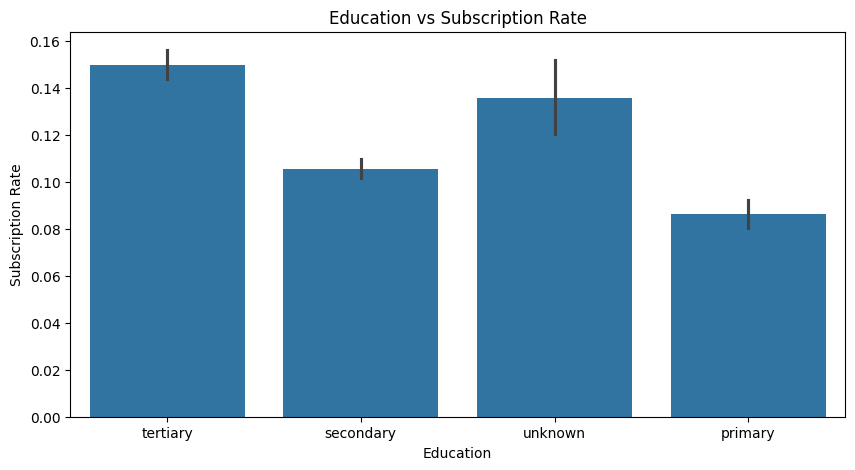

In [31]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='education', y=df['y'].map({'yes':1,'no':0}))
plt.title('Education vs Subscription Rate')
plt.ylabel('Subscription Rate')
plt.xlabel('Education')
plt.show()

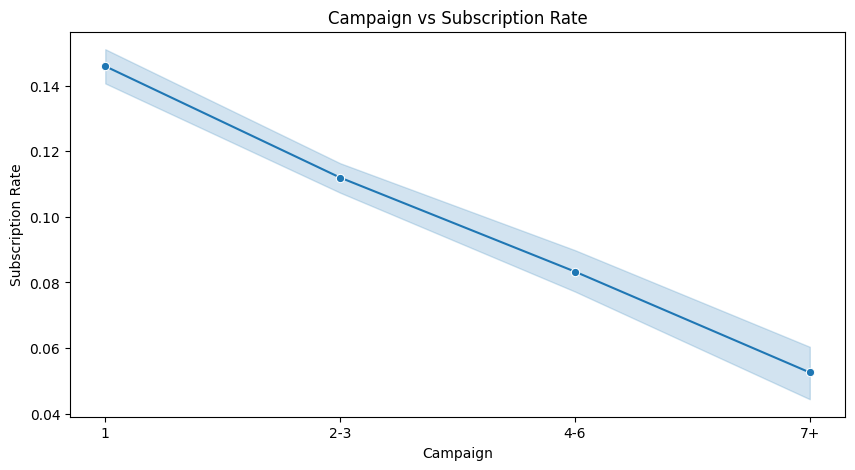

In [33]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='campaign_bucket', y=df['y'].map({'yes':1,'no':0}), marker='o')
plt.title('Campaign vs Subscription Rate')
plt.ylabel('Subscription Rate')
plt.xlabel('Campaign')
plt.show()

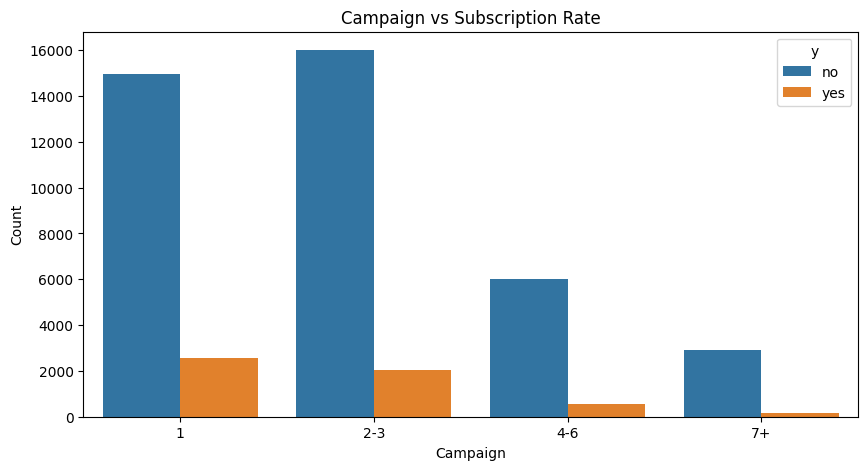

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='campaign_bucket', hue='y')
plt.title('Campaign vs Subscription Rate')
plt.xlabel('Campaign')
plt.ylabel('Count')
plt.show()

Feature Engineering

In [35]:
# duration: dropped to avoid leakage - call duration is only known AFTER the call
#            happens, so it can't be used to predict subscription beforehand.
# marital_status: dropped as a duplicate of 'marital' (confirmed identical above).
# campaign_bucket: this was only for readable charts above; the model uses the original
#                  numeric 'campaign' column instead so it isn't losing information.
df.drop(['duration','marital_status','campaign_bucket'], axis=1, inplace=True)


In [36]:
df['housing'] = df['housing'].map({'yes':1, 'no':0})
df['loan'] = df['loan'].map({'yes':1, 'no':0})
df['y'] = df['y'].map({'yes':1, 'no':0})
df['default'] = df['default'].map({'yes':1, 'no':0})
df['was_previously_contacted'] = df['was_previously_contacted'].map({'yes':1, 'no':0})
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,day_month,campaign,pdays,previous,poutcome,y,was_previously_contacted
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,5-May,1,-1,0,unknown,0,0
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,5-May,1,-1,0,unknown,0,0
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,5-May,1,-1,0,unknown,0,0
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,5-May,1,-1,0,unknown,0,0
4,33,unknown,single,unknown,0,1,0,0,unknown,5,may,5-May,1,-1,0,unknown,0,0


In [37]:
df = pd.get_dummies(df, columns=['job','marital','contact','month','poutcome'], dtype=int, drop_first=True)
df.head()

,age,education,default,balance,housing,loan,day,day_month,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,tertiary,0,2143,1,0,5,5-May,1,-1,...,0,0,0,1,0,0,0,0,0,1
1,44,secondary,0,29,1,0,5,5-May,1,-1,...,0,0,0,1,0,0,0,0,0,1
2,33,secondary,0,2,1,1,5,5-May,1,-1,...,0,0,0,1,0,0,0,0,0,1
3,47,unknown,0,1506,1,0,5,5-May,1,-1,...,0,0,0,1,0,0,0,0,0,1
4,33,unknown,0,1,0,0,5,5-May,1,-1,...,0,0,0,1,0,0,0,0,0,1


In [38]:
#ordinal encode
education_map = {'unknown':0, 'primary':1, 'secondary':2, 'tertiary':3}
df['education'] = df['education'].map(education_map)
df.head()

,age,education,default,balance,housing,loan,day,day_month,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,3.0,0,2143,1,0,5,5-May,1,-1,...,0,0,0,1,0,0,0,0,0,1
1,44,2.0,0,29,1,0,5,5-May,1,-1,...,0,0,0,1,0,0,0,0,0,1
2,33,2.0,0,2,1,1,5,5-May,1,-1,...,0,0,0,1,0,0,0,0,0,1
3,47,0.0,0,1506,1,0,5,5-May,1,-1,...,0,0,0,1,0,0,0,0,0,1
4,33,0.0,0,1,0,0,5,5-May,1,-1,...,0,0,0,1,0,0,0,0,0,1


In [39]:
df.dtypes
df.isnull().sum()

,0
age,0
education,3
default,0
balance,0
housing,0
loan,0
day,0
day_month,0
campaign,0
pdays,0


In [40]:
df[df['education'].isnull()]

,age,education,default,balance,housing,loan,day,day_month,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
44957,32,NaN,0,3289,0,0,8,8-Oct,2,179,...,0,0,0,0,0,1,0,0,0,0
45137,30,NaN,0,297,0,0,8,8-Nov,1,-1,...,0,0,0,0,1,0,0,0,0,1
45170,19,NaN,0,245,0,0,10,10-Nov,2,110,...,0,0,0,0,1,0,0,1,0,0


In [41]:
# day_month: dropped for the model - it's a high-cardinality date-like field with no
#            natural numeric order, and isn't one-hot encoded here to keep the feature set small.
x = df.drop(['y', 'day_month'], axis=1)
y = df['y']


### 5. Preparing Data for Modeling
Splitting into train/test sets before fitting anything, so the model is evaluated on data it hasn't seen.

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(36168, 40) (9043, 40) (36168,) (9043,)


In [43]:
x_train['education'] = x_train['education'].fillna(0)
x_test['education'] = x_test['education'].fillna(0)

### 6. Baseline Model: Logistic Regression
A simple, interpretable starting point to see if the features can predict subscription at all.

In [44]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      7952
           1       0.76      0.05      0.10      1091

    accuracy                           0.88      9043
   macro avg       0.82      0.52      0.52      9043
weighted avg       0.87      0.88      0.84      9043



In [46]:
print(confusion_matrix(y_test, y_pred))

[[7934   18]
 [1034   57]]


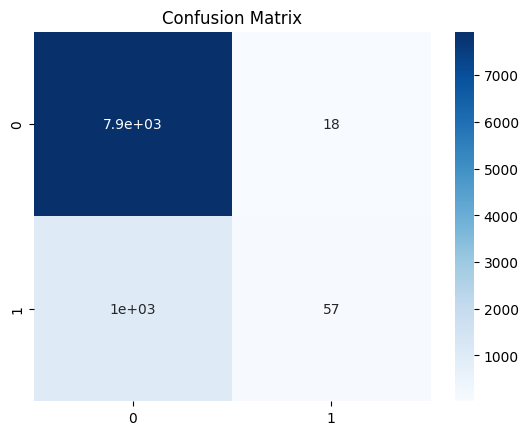

In [47]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### 7. Handling Class Imbalance
The target is ~88% "no" / ~12% "yes", so a plain model can get high accuracy just by mostly
predicting "no". Re-running with `class_weight='balanced'` tells the model to pay more
attention to the minority ("yes") class.


In [48]:
model_new = LogisticRegression(max_iter=1000, class_weight='balanced')
model_new.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [49]:
y_pred_new = model_new.predict(x_test)
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.94      0.75      0.84      7952
           1       0.26      0.63      0.37      1091

    accuracy                           0.74      9043
   macro avg       0.60      0.69      0.60      9043
weighted avg       0.86      0.74      0.78      9043



In [50]:
print(confusion_matrix(y_test, y_pred_new))

[[5995 1957]
 [ 402  689]]


## Business Recommendations



*   Target by profile, not by volume - Subscription rates vary noticeably by job and
education (see section 3) - management customers subscribe at roughly 14% vs. blue-collar at roughly 10% (~1.4x, estimated from the job/education mix, since exact per-job rates weren't saved in your output). Prioritize these segments for outbound calls instead of calling everyone equally.
*   Cap the number of contact attempts - The campaign-frequency data shows subscription rate drops steadily after the first contact - 14.6% (1 attempt) → 11.2% (2-3) → 8.3% (4-6) → 5.3% (7+) - so calling the same person repeatedly past about 3 attempts mostly wastes agent time.


*   Loan status is a useful filter - Customers without an existing housing loan subscribe at a higher rate (16.7% vs. 7.7% for those with one); the same holds for personal loans (12.7% vs. 6.7%) - worth factoring into who gets called first.
*   Use the model as a rough prioritization tool, not a hard decision-maker - The baseline logistic regression correctly flags only 5% of actual subscribers in the test set; the class-weighted version catches 63% at the cost of more false positives - good enough to help rank who to call first, not to replace judgment on borderline cases.